In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import butter, filtfilt, spectrogram, coherence
from scipy.fft import fft, fftfreq
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

In [ ]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12
np.random.seed(42)
torch.manual_seed(42)


In [ ]:
def generate_imu_data(duration=120, fs=50):
    """Генерация реалистичного сигнала IMU с дыханием, пульсом и артефактами"""
    t = np.arange(0, duration, 1/fs)
    n_points = len(t)

    # Дыхание с медленной модуляцией частоты и амплитуды
    breath_freq = 0.3 + 0.05 * np.sin(2*np.pi*0.008*t)  # меняется 0.25-0.35 Гц
    breath_phase = 2*np.pi * np.cumsum(breath_freq)/fs
    breath_amp = 0.8 + 0.1 * np.sin(2*np.pi*0.005*t)  # меняющаяся амплитуда
    breathing = breath_amp * np.sin(breath_phase)

    # Пульс с дыхательной аритмией и гармониками
    heart_base = 1.2
    heart_mod = 0.15 * np.sin(breath_phase)  # влияние дыхания на пульс
    heart_freq = heart_base + heart_mod
    heart_phase = 2*np.pi * np.cumsum(heart_freq)/fs
    heartbeat = (0.3 * np.sin(heart_phase) +
                 0.08 * np.sin(2*heart_phase) +  # 2-я гармоника
                 0.05 * np.sin(3*heart_phase))   # 3-я гармоника

    # Случайные движения (распределение Стьюдента для тяжелых хвостов)
    movements = np.random.standard_t(3, n_points) * 0.4
    # Сглаживаем движения
    window = np.ones(20)/20
    movements = np.convolve(movements, window, mode='same')

    # Добавляем специфические артефакты
    artifacts = np.zeros(n_points)
    # Короткий резкий артефакт (кашель/вздох)
    artifacts[1500:1520] = 1.2 * np.sin(2*np.pi*2.0*t[0:20])
    # Длительный артефакт (изменение положения)
    artifacts[3000:3100] = 0.6 * (1 + np.sin(2*np.pi*0.3*t[0:100]))
    # Случайные точечные выбросы
    outlier_indices = np.random.choice(n_points, size=50, replace=False)
    artifacts[outlier_indices] += 0.8 * np.random.randn(50)

    # Белый шум датчика
    sensor_noise = 0.15 * np.random.normal(size=n_points)

    # Смешиваем все компоненты
    mixed = (breathing + heartbeat + movements + artifacts + sensor_noise)

    return mixed, breathing, heartbeat, movements + artifacts, t

In [ ]:
# Генерируем данные
mixed, true_breath, true_heart, artifacts, t = generate_imu_data()
fs = 50

print(f"Длина сигнала: {len(mixed)} отсчетов")
print(f"Длительность: {len(mixed)/fs:.1f} секунд")
print(f"Частота дискретизации: {fs} Гц")

Длина сигнала: 6000 отсчетов
Длительность: 120.0 секунд
Частота дискретизации: 50 Гц


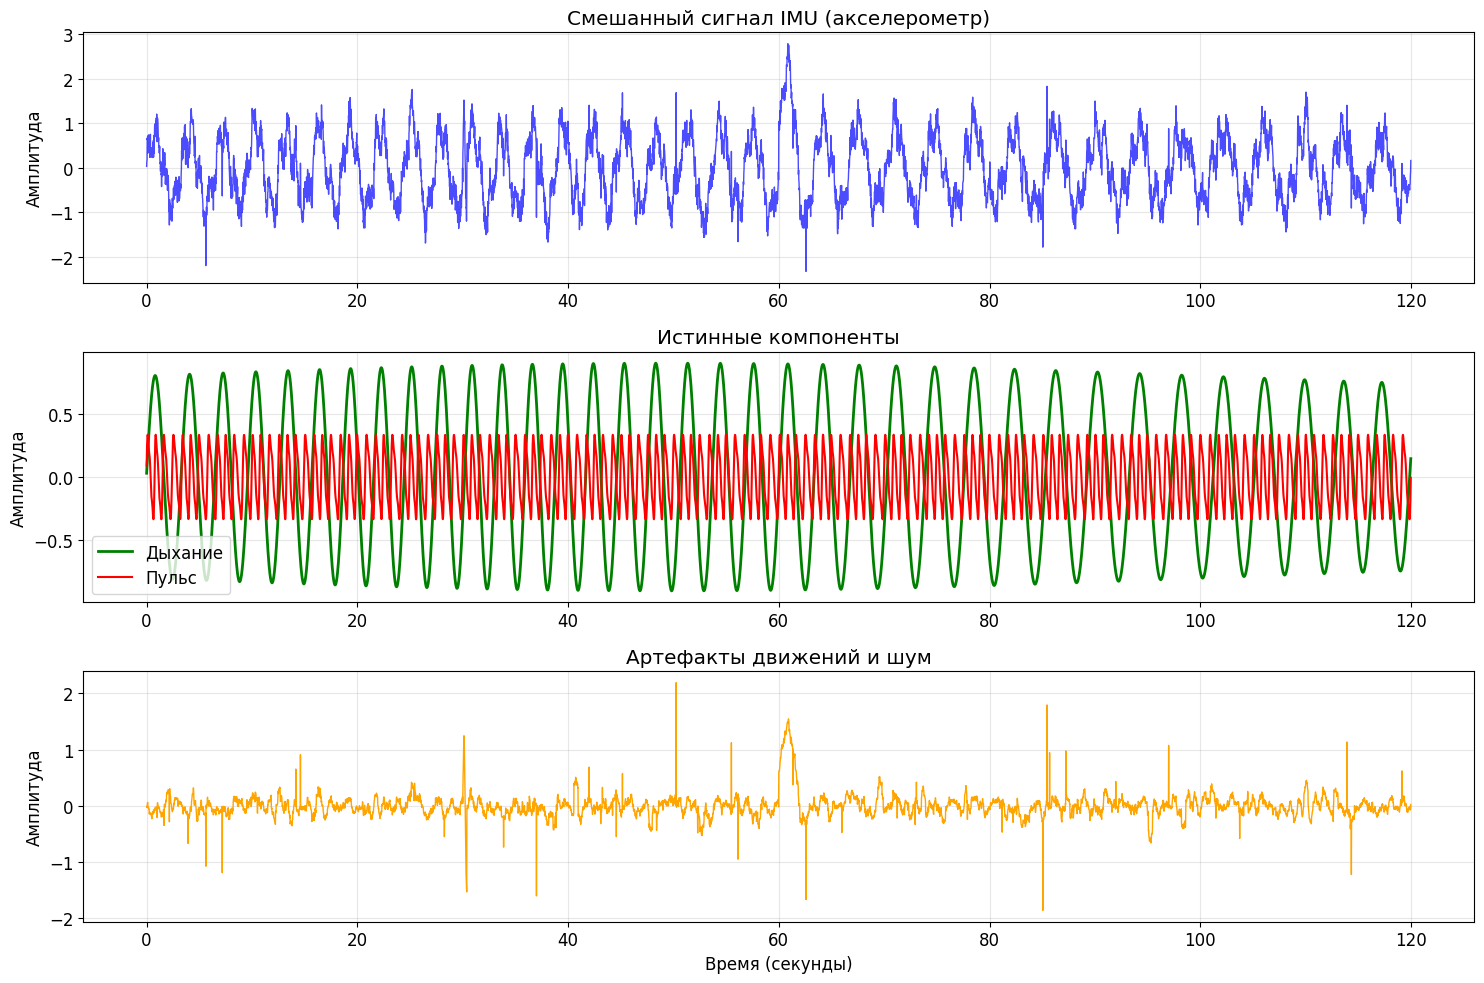

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Смешанный сигнал
axes[0].plot(t, mixed, 'b', alpha=0.7, linewidth=1)
axes[0].set_title('Смешанный сигнал IMU (акселерометр)')
axes[0].set_ylabel('Амплитуда')
axes[0].grid(True, alpha=0.3)

# Истинные компоненты
axes[1].plot(t, true_breath, 'g', label='Дыхание', linewidth=2)
axes[1].plot(t, true_heart, 'r', label='Пульс', linewidth=1.5)
axes[1].set_title('Истинные компоненты')
axes[1].set_ylabel('Амплитуда')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Артефакты и шум
axes[2].plot(t, artifacts, 'orange', linewidth=1)
axes[2].set_title('Артефакты движений и шум')
axes[2].set_ylabel('Амплитуда')
axes[2].set_xlabel('Время (секунды)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Полосовой фильтр Баттерворта"""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

In [ ]:
print("Применяем полосовые фильтры...")
start_time = time.time()

# Фильтры для дыхания и пульса
breath_filtered = butter_bandpass_filter(mixed, 0.1, 0.5, fs, order=6)
heart_filtered = butter_bandpass_filter(mixed, 0.8, 2.0, fs, order=6)

filter_time = time.time() - start_time
print(f"Время обработки фильтрами: {filter_time:.3f} сек")


Применяем полосовые фильтры...
Время обработки фильтрами: 0.007 сек


In [ ]:
def wavelet_separation(signal, wavelet='db6', level=8):
    """Разделение сигнала с помощью вейвлет-анализа"""
    # Вейвлет-разложение
    coeffs = pywt.wavedec(signal, wavelet, level=level)

    # Создаем копии коэффициентов для разных компонентов
    coeffs_breath = [np.zeros_like(coeffs[0])]  # cA8
    coeffs_heart = [np.zeros_like(coeffs[0])]   # cA8

    # Дыхание: уровни 6-8 (d8, d7, d6) - 0.1-0.78 Гц
    for i in range(1, 4):  # d8, d7, d6
        coeffs_breath.append(coeffs[i].copy())
        coeffs_heart.append(np.zeros_like(coeffs[i]))

    # Пульс: уровни 4-5 (d5, d4) - 0.78-3.125 Гц
    for i in range(4, 6):  # d5, d4
        coeffs_breath.append(np.zeros_like(coeffs[i]))
        coeffs_heart.append(coeffs[i].copy())

    # Обнуляем высокочастотные уровни для обоих
    for i in range(6, len(coeffs)):
        coeffs_breath.append(np.zeros_like(coeffs[i]))
        coeffs_heart.append(np.zeros_like(coeffs[i]))

    # Обратное преобразование
    breath = pywt.waverec(coeffs_breath, wavelet)
    heart = pywt.waverec(coeffs_heart, wavelet)

    return breath, heart


In [ ]:
print("Применяем вейвлет-анализ...")
start_time = time.time()

breath_wavelet, heart_wavelet = wavelet_separation(mixed)

wavelet_time = time.time() - start_time
print(f"Время обработки вейвлетами: {wavelet_time:.3f} сек")

Применяем вейвлет-анализ...
Время обработки вейвлетами: 0.008 сек


In [ ]:
class NeuralSeparator(nn.Module):
    def __init__(self, input_size=6000):
        super().__init__()

        # Encoder с разными масштабами
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=101, padding=50),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=51, padding=25),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=25, padding=12),
            nn.ReLU(),
        )

        # Decoders для каждого компонента
        self.decoder_breath = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=51, padding=25),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, kernel_size=25, padding=12),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 1, kernel_size=15, padding=7),
            nn.Tanh()
        )

        self.decoder_heart = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=25, padding=12),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, kernel_size=15, padding=7),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 1, kernel_size=11, padding=5),
            nn.Tanh()
        )

    def forward(self, x):
        features = self.encoder(x)
        breath = self.decoder_breath(features)
        heart = self.decoder_heart(features)
        return breath, heart

In [ ]:
def prepare_neural_network(mixed, true_breath, true_heart, epochs=500):
    """Подготовка и обучение нейросетевой модели"""

    # Подготовка данных
    scaler = StandardScaler()
    signal_scaled = scaler.fit_transform(mixed.reshape(-1, 1)).flatten()

    # Преобразование в тензоры
    signal_tensor = torch.FloatTensor(signal_scaled).unsqueeze(0).unsqueeze(0)
    breath_tensor = torch.FloatTensor(true_breath).unsqueeze(0).unsqueeze(0)
    heart_tensor = torch.FloatTensor(true_heart).unsqueeze(0).unsqueeze(0)

    # Модель и оптимизатор
    model = NeuralSeparator()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    print("Обучение нейросети...")
    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        breath_pred, heart_pred = model(signal_tensor)

        # Функция потерь с весами
        loss_breath = criterion(breath_pred, breath_tensor)
        loss_heart = criterion(heart_pred, heart_tensor)
        loss = 0.6 * loss_breath + 0.4 * loss_heart

        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if epoch % 100 == 0:
            print(f"Эпоха {epoch}, Loss: {loss.item():.6f}")

    # Предсказание на обучающих данных
    with torch.no_grad():
        breath_pred, heart_pred = model(signal_tensor)
        breath_nn = breath_pred.squeeze().numpy()
        heart_nn = heart_pred.squeeze().numpy()

    return breath_nn, heart_nn, losses


In [ ]:
print("Обучаем нейросеть...")
start_time = time.time()

breath_nn, heart_nn, losses = prepare_neural_network(mixed, true_breath, true_heart, epochs=800)

neural_time = time.time() - start_time
print(f"Время обучения и обработки нейросетью: {neural_time:.3f} сек")

Обучаем нейросеть...
Обучение нейросети...
Эпоха 0, Loss: 0.229587
Эпоха 100, Loss: 0.001902
Эпоха 200, Loss: 0.000725
Эпоха 300, Loss: 0.000305
Эпоха 400, Loss: 0.000180
Эпоха 500, Loss: 0.000123
Эпоха 600, Loss: 0.000085
Эпоха 700, Loss: 0.000063
Время обучения и обработки нейросетью: 857.593 сек


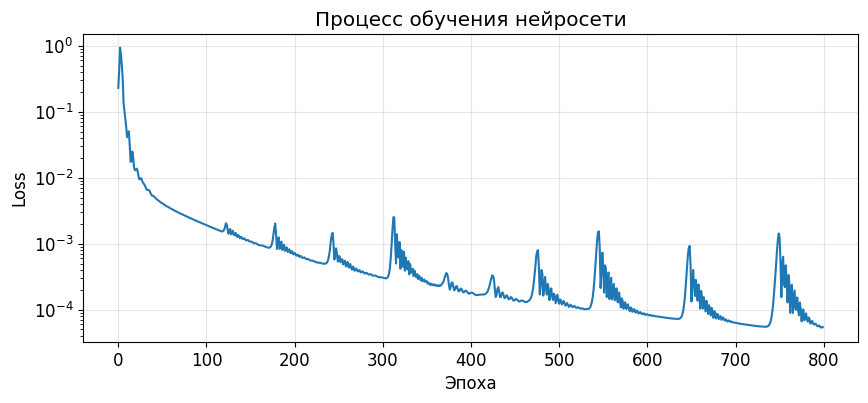

In [ ]:
# Визуализация процесса обучения
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title('Процесс обучения нейросети')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def calculate_metrics(pred, true, component_name=""):
    """Вычисление метрик качества"""
    # SNR
    signal_power = np.mean(true**2)
    noise_power = np.mean((pred - true)**2)
    snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else 100

    # Корреляция
    correlation = np.corrcoef(pred, true)[0, 1]

    # Среднеквадратичная ошибка (нормированная)
    mse = np.mean((pred - true)**2) / np.var(true)

    return snr, correlation, mse

In [ ]:
# Вычисляем метрики для всех методов
metrics_breath = {}
metrics_heart = {}

methods = {
    'Фильтры': (breath_filtered, heart_filtered),
    'Вейвлеты': (breath_wavelet, heart_wavelet),
    'Нейросеть': (breath_nn, heart_nn)
}

for method_name, (breath_pred, heart_pred) in methods.items():
    metrics_breath[method_name] = calculate_metrics(breath_pred, true_breath, "Дыхание")
    metrics_heart[method_name] = calculate_metrics(heart_pred, true_heart, "Пульс")

# Время обработки
times = {
    'Фильтры': filter_time,
    'Вейвлеты': wavelet_time,
    'Нейросеть': neural_time
}

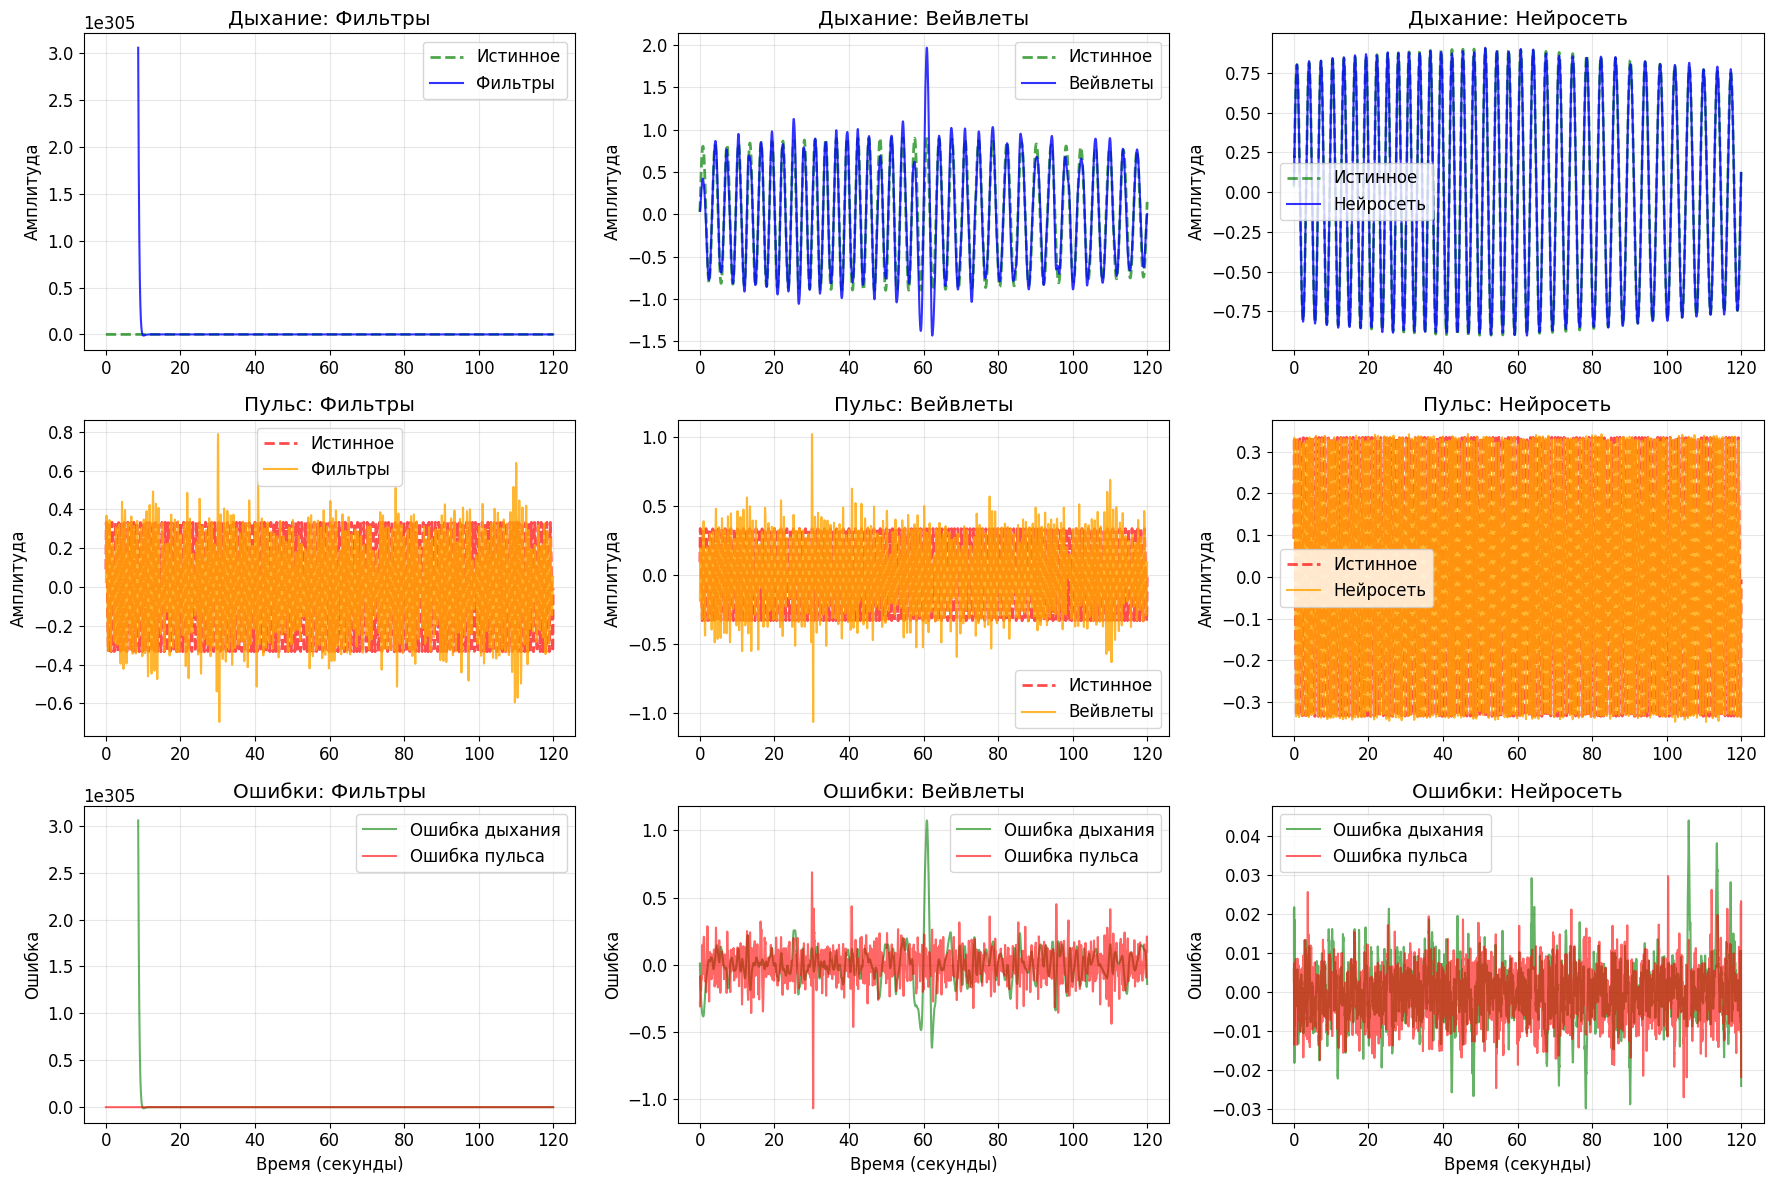

In [ ]:
# Создаем большую фигуру для сравнения
fig = plt.figure(figsize=(18, 12))

# Первый ряд: Дыхание
axes = []
for i, (method_name, (breath_pred, _)) in enumerate(methods.items()):
    ax = plt.subplot(3, 3, i + 1)
    ax.plot(t, true_breath, 'g--', label='Истинное', alpha=0.7, linewidth=2)
    ax.plot(t, breath_pred, 'b', label=f'{method_name}', alpha=0.8)
    ax.set_title(f'Дыхание: {method_name}')
    ax.set_ylabel('Амплитуда')
    ax.legend()
    ax.grid(True, alpha=0.3)
    axes.append(ax)

# Второй ряд: Пульс
for i, (method_name, (_, heart_pred)) in enumerate(methods.items()):
    ax = plt.subplot(3, 3, i + 4)
    ax.plot(t, true_heart, 'r--', label='Истинное', alpha=0.7, linewidth=2)
    ax.plot(t, heart_pred, 'orange', label=f'{method_name}', alpha=0.8)
    ax.set_title(f'Пульс: {method_name}')
    ax.set_ylabel('Амплитуда')
    ax.legend()
    ax.grid(True, alpha=0.3)
    axes.append(ax)

# Третий ряд: Ошибки
for i, (method_name, (breath_pred, heart_pred)) in enumerate(methods.items()):
    ax = plt.subplot(3, 3, i + 7)
    error_breath = breath_pred - true_breath
    error_heart = heart_pred - true_heart
    ax.plot(t, error_breath, 'g', label='Ошибка дыхания', alpha=0.6)
    ax.plot(t, error_heart, 'r', label='Ошибка пульса', alpha=0.6)
    ax.set_title(f'Ошибки: {method_name}')
    ax.set_xlabel('Время (секунды)')
    ax.set_ylabel('Ошибка')
    ax.legend()
    ax.grid(True, alpha=0.3)
    axes.append(ax)

plt.tight_layout()
plt.show()


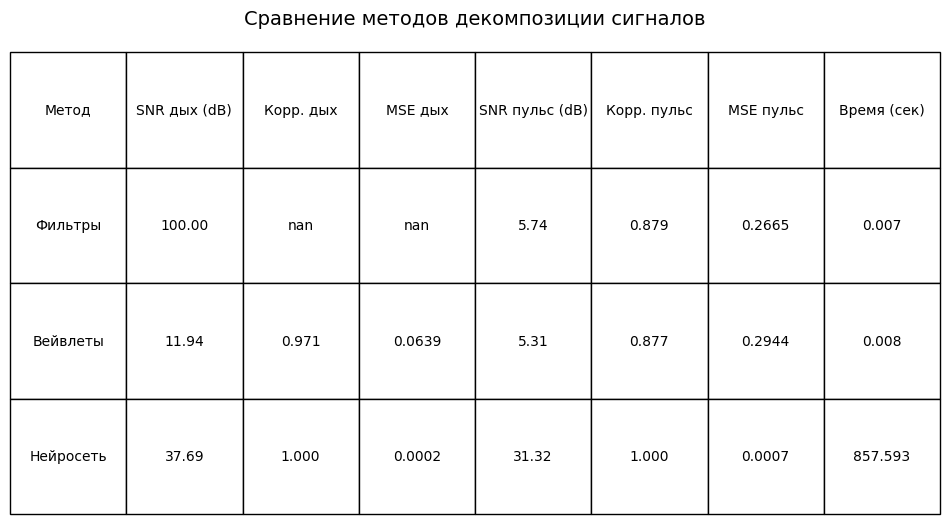

In [ ]:
# Создаем красивую таблицу метрик
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

# Подготовка данных для таблицы
table_data = []
headers = ['Метод', 'SNR дых (dB)', 'Корр. дых', 'MSE дых',
           'SNR пульс (dB)', 'Корр. пульс', 'MSE пульс', 'Время (сек)']

for method_name in methods.keys():
    snr_b, corr_b, mse_b = metrics_breath[method_name]
    snr_h, corr_h, mse_h = metrics_heart[method_name]
    time_val = times[method_name]

    table_data.append([
        method_name,
        f'{snr_b:.2f}',
        f'{corr_b:.3f}',
        f'{mse_b:.4f}',
        f'{snr_h:.2f}',
        f'{corr_h:.3f}',
        f'{mse_h:.4f}',
        f'{time_val:.3f}'
    ])

# Создаем таблицу
table = ax.table(cellText=table_data,
                colLabels=headers,
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Подсветка лучших результатов
best_snr_breath = max(metrics_breath[m][0] for m in methods.keys())
best_snr_heart = max(metrics_heart[m][0] for m in methods.keys())
best_corr_breath = max(metrics_breath[m][1] for m in methods.keys())
best_corr_heart = max(metrics_heart[m][1] for m in methods.keys())

plt.title('Сравнение методов декомпозиции сигналов', fontsize=14, pad=20)
plt.show()


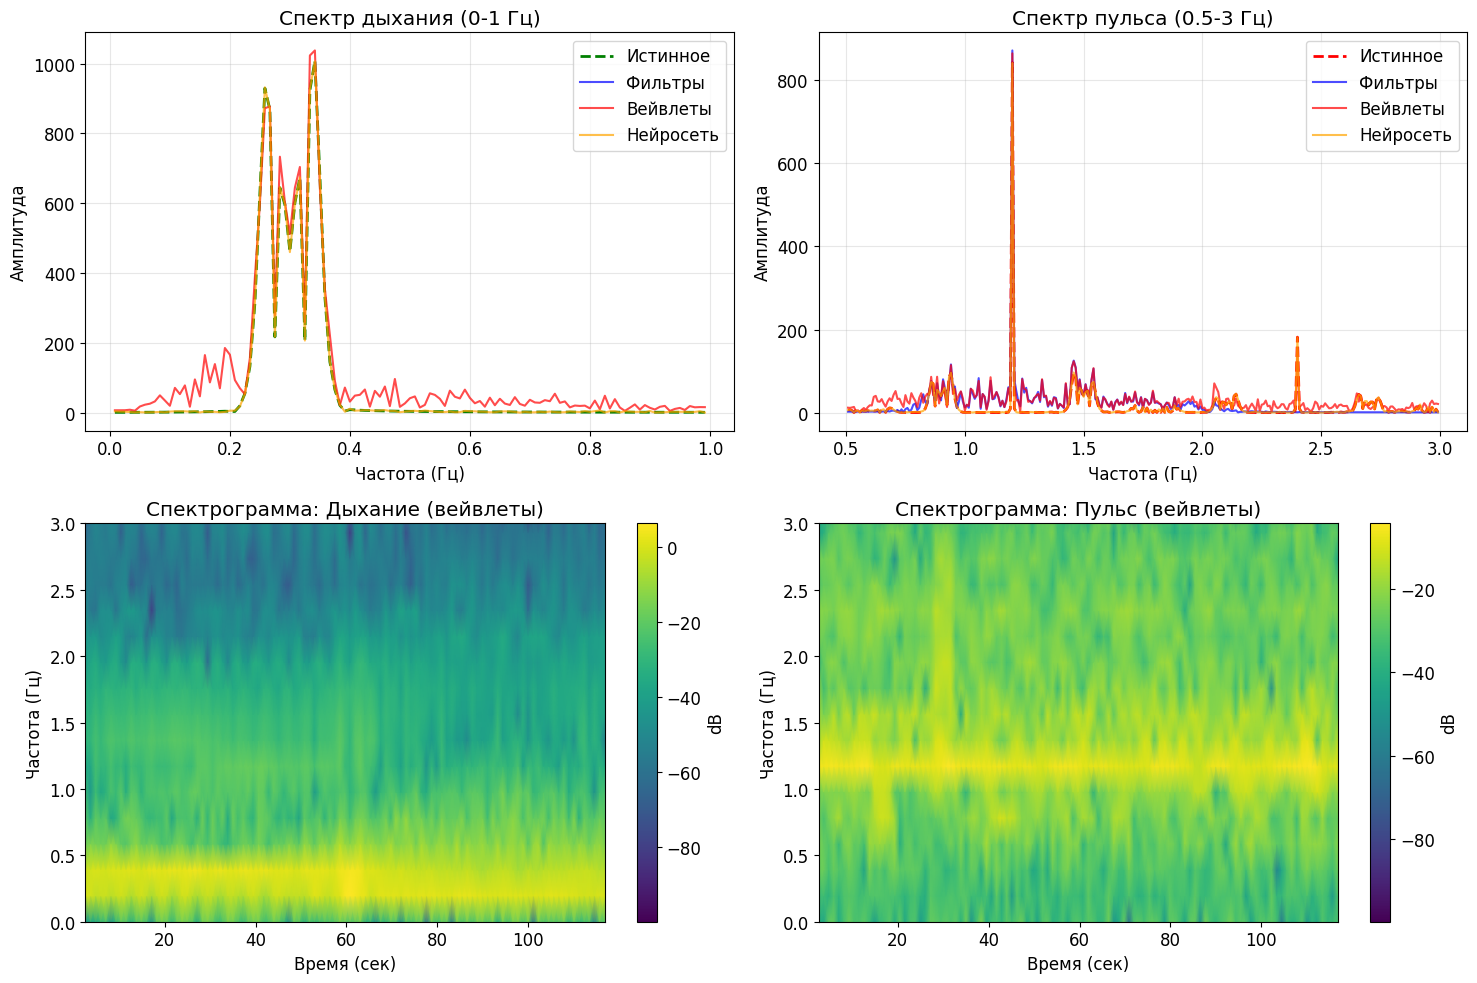

In [ ]:
# Спектральный анализ для качественного сравнения
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Спектр дыхания
freqs = fftfreq(len(t), 1/fs)
breath_spectrum_true = np.abs(fft(true_breath))
breath_spectrum_filter = np.abs(fft(breath_filtered))
breath_spectrum_wavelet = np.abs(fft(breath_wavelet))
breath_spectrum_nn = np.abs(fft(breath_nn))

mask = (freqs > 0) & (freqs < 1.0)  # Смотрим до 1 Гц

axes[0, 0].plot(freqs[mask], breath_spectrum_true[mask], 'g--', label='Истинное', linewidth=2)
axes[0, 0].plot(freqs[mask], breath_spectrum_filter[mask], 'b', label='Фильтры', alpha=0.7)
axes[0, 0].plot(freqs[mask], breath_spectrum_wavelet[mask], 'r', label='Вейвлеты', alpha=0.7)
axes[0, 0].plot(freqs[mask], breath_spectrum_nn[mask], 'orange', label='Нейросеть', alpha=0.7)
axes[0, 0].set_title('Спектр дыхания (0-1 Гц)')
axes[0, 0].set_xlabel('Частота (Гц)')
axes[0, 0].set_ylabel('Амплитуда')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Спектр пульса
heart_spectrum_true = np.abs(fft(true_heart))
heart_spectrum_filter = np.abs(fft(heart_filtered))
heart_spectrum_wavelet = np.abs(fft(heart_wavelet))
heart_spectrum_nn = np.abs(fft(heart_nn))

mask_heart = (freqs > 0.5) & (freqs < 3.0)  # Смотрим 0.5-3 Гц

axes[0, 1].plot(freqs[mask_heart], heart_spectrum_true[mask_heart], 'r--', label='Истинное', linewidth=2)
axes[0, 1].plot(freqs[mask_heart], heart_spectrum_filter[mask_heart], 'b', label='Фильтры', alpha=0.7)
axes[0, 1].plot(freqs[mask_heart], heart_spectrum_wavelet[mask_heart], 'r', label='Вейвлеты', alpha=0.7)
axes[0, 1].plot(freqs[mask_heart], heart_spectrum_nn[mask_heart], 'orange', label='Нейросеть', alpha=0.7)
axes[0, 1].set_title('Спектр пульса (0.5-3 Гц)')
axes[0, 1].set_xlabel('Частота (Гц)')
axes[0, 1].set_ylabel('Амплитуда')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Спектрограммы для визуализации временно-частотных характеристик
def plot_spectrogram(ax, signal, title, fs=50):
    f, t_spec, Sxx = spectrogram(signal, fs, nperseg=256, noverlap=200)
    im = ax.pcolormesh(t_spec, f, 10*np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
    ax.set_ylabel('Частота (Гц)')
    ax.set_xlabel('Время (сек)')
    ax.set_title(title)
    ax.set_ylim(0, 3)
    plt.colorbar(im, ax=ax, label='dB')

plot_spectrogram(axes[1, 0], breath_wavelet, 'Спектрограмма: Дыхание (вейвлеты)')
plot_spectrogram(axes[1, 1], heart_wavelet, 'Спектрограмма: Пульс (вейвлеты)')

plt.tight_layout()
plt.show()


In [ ]:
# Финальные выводы
print("="*60)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("="*60)

best_breath_method = max(methods.keys(), key=lambda m: metrics_breath[m][0])
best_heart_method = max(methods.keys(), key=lambda m: metrics_heart[m][0])
fastest_method = min(times.keys(), key=lambda m: times[m])

print(f"Лучший метод для дыхания: {best_breath_method} (SNR: {metrics_breath[best_breath_method][0]:.2f} dB)")
print(f"Лучший метод для пульса: {best_heart_method} (SNR: {metrics_heart[best_heart_method][0]:.2f} dB)")
print(f"Самый быстрый метод: {fastest_method} ({times[fastest_method]:.3f} сек)")

print("\nРекомендации:")
print("• Полосовые фильтры: Быстрые, подходят для реального времени")
print("• Вейвлет-анализ: Точные, хорошо справляются с нестационарностями")
print("• Нейросети: Максимальное качество, но требуют обучения")
print("="*60)

ИТОГОВЫЕ ВЫВОДЫ
Лучший метод для дыхания: Фильтры (SNR: 100.00 dB)
Лучший метод для пульса: Нейросеть (SNR: 31.32 dB)
Самый быстрый метод: Фильтры (0.007 сек)

Рекомендации:
• Полосовые фильтры: Быстрые, подходят для реального времени
• Вейвлет-анализ: Точные, хорошо справляются с нестационарностями
• Нейросети: Максимальное качество, но требуют обучения
